In [116]:
import pandas as pd
from pathlib import Path

years = ['2021', '2022', '2023', '2024']

dfs = [pd.read_csv(f"atp_matches_{year}.csv") for year in years]
df = pd.concat(dfs, ignore_index=True)

df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d')
df = df.sort_values('tourney_date').reset_index(drop=True)

print(df.shape)
print(df.info())

(11712, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11712 entries, 0 to 11711
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tourney_id          11712 non-null  object        
 1   tourney_name        11712 non-null  object        
 2   surface             11659 non-null  object        
 3   draw_size           11712 non-null  int64         
 4   tourney_level       11712 non-null  object        
 5   tourney_date        11712 non-null  datetime64[ns]
 6   match_num           11712 non-null  int64         
 7   winner_id           11712 non-null  int64         
 8   winner_seed         4929 non-null   float64       
 9   winner_entry        1795 non-null   object        
 10  winner_name         11712 non-null  object        
 11  winner_hand         11712 non-null  object        
 12  winner_ht           11665 non-null  float64       
 13  winner_ioc          11712 non-null

In [117]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [118]:
import pandas as pd
from sklearn.utils import shuffle

# Step 1: Copy data
df_model = df.copy()

# Step 2: Drop post-match info
post_match_cols = [col for col in df_model.columns if col.startswith(('w_', 'l_'))] + ['score', 'minutes', 'winner_rank_points', 'loser_rank_points']
df_model.drop(columns=post_match_cols, inplace=True)

# Step 3: Fill and clean pre-match features
df_model['winner_seed'].fillna(0, inplace=True)
df_model['loser_seed'].fillna(0, inplace=True)
df_model['winner_entry'].fillna('N', inplace=True)
df_model['loser_entry'].fillna('N', inplace=True)

for col in ['winner_age', 'loser_age', 'winner_ht', 'loser_ht']:
    df_model[col].fillna(df_model[col].median(), inplace=True)

df_model.dropna(subset=['winner_rank', 'loser_rank'], inplace=True)

df_model['tourney_date'] = pd.to_datetime(df_model['tourney_date'], format='%Y%m%d')
df_model['year'] = df_model['tourney_date'].dt.year

round_order = {'R128':1, 'R64':2, 'R32':3, 'R16':4, 'QF':5, 'SF':6, 'F':7}
df_model['round_encoded'] = df_model['round'].map(round_order)

# Step 4: Rename columns and create symmetrical dataset
def create_symmetric_rows(row):
    p1 = {
        'player_1': row['winner_name'],
        'player_2': row['loser_name'],
        'p1_rank': row['winner_rank'],
        'p2_rank': row['loser_rank'],
        'p1_age': row['winner_age'],
        'p2_age': row['loser_age'],
        'p1_ht': row['winner_ht'],
        'p2_ht': row['loser_ht'],
        'p1_seed': row['winner_seed'],
        'p2_seed': row['loser_seed'],
        'surface': row['surface'],
        'round': row['round_encoded'],
        'year': row['year'],
        'target': 1
    }
    p2 = p1.copy()
    p2['player_1'], p2['player_2'] = p1['player_2'], p1['player_1']
    p2['p1_rank'], p2['p2_rank'] = p1['p2_rank'], p1['p1_rank']
    p2['p1_age'], p2['p2_age'] = p1['p2_age'], p1['p1_age']
    p2['p1_ht'], p2['p2_ht'] = p1['p2_ht'], p1['p1_ht']
    p2['p1_seed'], p2['p2_seed'] = p1['p2_seed'], p1['p1_seed']
    p2['target'] = 0
    return pd.DataFrame([p1, p2])

symmetric_df = pd.concat([create_symmetric_rows(row) for _, row in df_model.iterrows()], ignore_index=True)
symmetric_df = shuffle(symmetric_df, random_state=42).reset_index(drop=True)


In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.model_selection import train_test_split

# Only use numeric features + surface/round for now
feature_cols = [
    'p1_rank', 'p2_rank',
    'p1_age', 'p2_age',
    'p1_ht', 'p2_ht',
    'p1_seed', 'p2_seed',
    'round',  # encoded
    'surface'
]

# One-hot encode categorical column
X = pd.get_dummies(symmetric_df[feature_cols], columns=['surface'])
y = symmetric_df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [120]:
# Check how many NaNs are in your training set
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in y_train:", y_train.isnull().sum())


NaNs in X_train: 1524
NaNs in y_train: 0


In [121]:
# Drop rows with NaNs from X and align y accordingly
X_train_clean = X_train.dropna()
y_train_clean = y_train.loc[X_train_clean.index]

X_test_clean = X_test.dropna()
y_test_clean = y_test.loc[X_test_clean.index]

# Fit the model on cleaned data
model = LogisticRegression(max_iter=1000)
model.fit(X_train_clean, y_train_clean)

# Predict and evaluate
y_pred = model.predict(X_test_clean)
print("Accuracy:", accuracy_score(y_test_clean, y_pred))


Accuracy: 0.6111634479510127


In [122]:
round_order = {'R128': 1, 'R64': 2, 'R32': 3, 'R16': 4, 'QF': 5, 'SF': 6, 'F': 7}
df['round_encoded'] = df['round'].map(round_order)

In [123]:
# 1. Create 'player 1' = winner, 'player 2' = loser columns
df['p1_rank'] = df['winner_rank']
df['p2_rank'] = df['loser_rank']

df['p1_age'] = df['winner_age']
df['p2_age'] = df['loser_age']

df['p1_ht'] = df['winner_ht']
df['p2_ht'] = df['loser_ht']

df['p1_seed'] = df['winner_seed'].fillna(0)
df['p2_seed'] = df['loser_seed'].fillna(0)

# 2. Encode 'round'
round_order = {'R128': 1, 'R64': 2, 'R32': 3, 'R16': 4, 'QF': 5, 'SF': 6, 'F': 7}
df['round_encoded'] = df['round'].map(round_order)

# 3. One-hot encode surface
surface_dummies = pd.get_dummies(df['surface'], prefix='surface')
df = pd.concat([df, surface_dummies], axis=1)

# 4. Define the outcome (player 1 = winner)
df['outcome'] = 1


In [124]:
def create_symmetrical_df(df_original):
    rows = []
    for _, row in df_original.iterrows():
        # Player 1 = winner
        row1 = {
            'p1_rank': row['winner_rank'],
            'p2_rank': row['loser_rank'],
            'p1_age': row['winner_age'],
            'p2_age': row['loser_age'],
            'p1_ht': row['winner_ht'],
            'p2_ht': row['loser_ht'],
            'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'round_encoded': round_order.get(row['round'], 0),
            'surface': row['surface'],
            'outcome': 1
        }

        # Player 1 = loser
        row2 = {
            'p1_rank': row['loser_rank'],
            'p2_rank': row['winner_rank'],
            'p1_age': row['loser_age'],
            'p2_age': row['winner_age'],
            'p1_ht': row['loser_ht'],
            'p2_ht': row['winner_ht'],
            'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'round_encoded': round_order.get(row['round'], 0),
            'surface': row['surface'],
            'outcome': 0
        }

        rows.append(row1)
        rows.append(row2)

    return pd.DataFrame(rows)

# Create symmetrical dataset
df_symmetric = create_symmetrical_df(df)


In [125]:
# One-hot encode surface
surface_dummies = pd.get_dummies(df_symmetric['surface'], prefix='surface')
df_symmetric = pd.concat([df_symmetric, surface_dummies], axis=1)

# Define final feature list
features = ['p1_rank', 'p2_rank', 'p1_age', 'p2_age', 'p1_ht', 'p2_ht',
            'p1_seed', 'p2_seed', 'round_encoded'] + list(surface_dummies.columns)

# Prepare data
X = df_symmetric[features].dropna()
y = df_symmetric.loc[X.index, 'outcome']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict & evaluate
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.620981754995656
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.62      0.62      2264
           1       0.63      0.62      0.62      2340

    accuracy                           0.62      4604
   macro avg       0.62      0.62      0.62      4604
weighted avg       0.62      0.62      0.62      4604



In [126]:
import re

def parse_score(score):
    if pd.isnull(score):
        return None, None

    sets = score.strip().split()
    winner_sets = 0
    loser_sets = 0
    games_winner = 0
    games_loser = 0

    for s in sets:
        s = re.sub(r'[^\d\-]', '', s)  # strip any tiebreak junk
        if '-' not in s:
            continue
        try:
            g1, g2 = map(int, s.split('-'))
        except ValueError:
            continue

        if g1 > g2:
            winner_sets += 1
            games_winner += g1
            games_loser += g2
        else:
            loser_sets += 1
            games_winner += g2
            games_loser += g1

    sets_lost = loser_sets
    if games_winner + games_loser == 0:
        game_win_pct = None
    else:
        game_win_pct = games_winner / (games_winner + games_loser)

    return sets_lost, game_win_pct

# Apply to your original dataset
df['sets_lost'], df['game_win_pct'] = zip(*df['score'].map(parse_score))


In [127]:
from sklearn.linear_model import LinearRegression

def create_symmetrical_df(df_original):
    rows = []
    for _, row in df_original.iterrows():
        row1 = {
            'p1_rank': row['winner_rank'],
            'p2_rank': row['loser_rank'],
            'p1_age': row['winner_age'],
            'p2_age': row['loser_age'],
            'p1_ht': row['winner_ht'],
            'p2_ht': row['loser_ht'],
            'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': row['sets_lost'],
            'game_win_pct': row['game_win_pct'],
            'outcome': 1
        }
        row2 = {
            'p1_rank': row['loser_rank'],
            'p2_rank': row['winner_rank'],
            'p1_age': row['loser_age'],
            'p2_age': row['winner_age'],
            'p1_ht': row['loser_ht'],
            'p2_ht': row['winner_ht'],
            'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': 3 - row['sets_lost'] if row['sets_lost'] is not None else None,
            'game_win_pct': 1 - row['game_win_pct'] if row['game_win_pct'] is not None else None,
            'outcome': 0
        }
        rows.extend([row1, row2])
    return pd.DataFrame(rows)


In [128]:
df_symmetric = create_symmetrical_df(df)

In [129]:
y_sets_lost = df_symmetric.loc[X.index, 'sets_lost']

In [130]:
# One-hot encode surface
surface_dummies = pd.get_dummies(df_symmetric['surface'], prefix='surface')
df_symmetric = pd.concat([df_symmetric, surface_dummies], axis=1)

# Update features list
features = ['p1_rank', 'p2_rank', 'p1_age', 'p2_age',
            'p1_ht', 'p2_ht', 'p1_seed', 'p2_seed',
            'round_encoded', 'surface_Clay', 'surface_Grass', 'surface_Hard']

In [131]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

# Ensure X and targets are aligned and clean
X = df_symmetric[features].dropna()

# Align targets with cleaned X
y_sets_lost = df_symmetric.loc[X.index, 'sets_lost']
y_game_pct = df_symmetric.loc[X.index, 'game_win_pct']
y_outcome = df_symmetric.loc[X.index, 'outcome']

# Drop any rows with missing targets
mask = y_sets_lost.notnull() & y_game_pct.notnull() & y_outcome.notnull()
X = X[mask]
y_sets_lost = y_sets_lost[mask]
y_game_pct = y_game_pct[mask]
y_outcome = y_outcome[mask]

# Train/test split for classifiers and regressors
X_train, X_test, y_outcome_train, y_outcome_test = train_test_split(X, y_outcome, test_size=0.2, random_state=42)
X_train_sets, X_test_sets, y_sets_train, y_sets_test = train_test_split(X, y_sets_lost, test_size=0.2, random_state=42)
X_train_games, X_test_games, y_games_train, y_games_test = train_test_split(X, y_game_pct, test_size=0.2, random_state=42)

# Train models
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_outcome_train)

sets_model = LinearRegression()
sets_model.fit(X_train_sets, y_sets_train)

games_model = LinearRegression()
games_model.fit(X_train_games, y_games_train)

# Inference function
def predict_match(input_features):
    win_prob = model.predict_proba([input_features])[0][1]
    predicted_winner = "Player 1" if win_prob > 0.5 else "Player 2"
    expected_sets_lost = sets_model.predict([input_features])[0]
    expected_game_win_pct = games_model.predict([input_features])[0]

    return {
        "predicted_winner": predicted_winner,
        "win_probability": round(win_prob, 2),
        "expected_sets_lost": round(expected_sets_lost, 2),
        "expected_game_win_pct": round(expected_game_win_pct, 2)
    }


In [132]:
import numpy as np

# Sample input row (ensure it's float type)
sample_input = X.iloc[0].values.astype(np.float64)

# Run prediction
result = predict_match(sample_input)
print(result)


{'predicted_winner': 'Player 2', 'win_probability': 0.48, 'expected_sets_lost': 1.48, 'expected_game_win_pct': 0.5}


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [133]:
df['delta_aces'] = df['w_ace'] - df['l_ace']

df['delta_1stServePct'] = (df['w_1stIn'] / df['w_svpt']) - (df['l_1stIn'] / df['l_svpt'])

df['delta_1stServeWinPct'] = (df['w_1stWon'] / df['w_1stIn']) - (df['l_1stWon'] / df['l_1stIn'])

df['delta_2ndServeWinPct'] = (df['w_2ndWon'] / (df['w_svpt'] - df['w_1stIn'])) - (df['l_2ndWon'] / (df['l_svpt'] - df['l_1stIn']))

df['delta_bpSavedPct'] = (df['w_bpSaved'] / df['w_bpFaced'].replace(0, 1)) - (df['l_bpSaved'] / df['l_bpFaced'].replace(0, 1))

df['delta_df'] = df['w_df'] - df['l_df']

df['delta_svpt'] = df['w_svpt'] - df['l_svpt']

df['delta_rank'] = df['loser_rank'] - df['winner_rank']  # higher rank = lower number, so we reverse

features = [
    'delta_aces',
    'delta_1stServePct',
    'delta_1stServeWinPct',
    'delta_2ndServeWinPct',
    'delta_bpSavedPct',
    'delta_df',
    'delta_svpt',
    'delta_rank'
]

In [134]:
import numpy as np

custom_input = np.array([
    3,    # p1_rank
    12,   # p2_rank
    26,   # p1_age
    30,   # p2_age
    188,  # p1_ht
    185,  # p2_ht
    2,    # p1_seed
    0,    # p2_seed
    5,    # round_encoded (QF)
    0,    # surface_Clay
    1,    # surface_Grass
    0     # surface_Hard
], dtype=np.float64)

result = predict_match(custom_input)
print(result)

{'predicted_winner': 'Player 1', 'win_probability': 0.55, 'expected_sets_lost': 1.4, 'expected_game_win_pct': 0.52}


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [135]:
def make_input(p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
               p1_seed, p2_seed, round_encoded, surface):
    surface_map = {'Clay': [1, 0, 0], 'Grass': [0, 1, 0], 'Hard': [0, 0, 1]}
    surface_encoded = surface_map.get(surface, [0, 0, 1])  # Default to Hard

    return np.array([
        p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
        p1_seed, p2_seed, round_encoded
    ] + surface_encoded, dtype=np.float64)

In [136]:
custom_input = make_input(
    p1_rank=3, p2_rank=12,
    p1_age=26, p2_age=30,
    p1_ht=188, p2_ht=185,
    p1_seed=2, p2_seed=0,
    round_encoded=5,  # QF
    surface='Grass'
)

result = predict_match(custom_input)
print(result)

{'predicted_winner': 'Player 1', 'win_probability': 0.55, 'expected_sets_lost': 1.4, 'expected_game_win_pct': 0.52}


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [137]:
print(X.var())


p1_rank          9021.261279
p2_rank          9021.261279
p1_age             19.965041
p2_age             19.965041
p1_ht              46.374166
p2_ht              46.374166
p1_seed            37.012558
p2_seed            37.012558
round_encoded       2.132473
surface_Clay        0.216187
surface_Grass       0.104724
surface_Hard        0.245778
dtype: float64


In [138]:
def create_symmetrical_df_with_names(df_original):
    rows = []
    for _, row in df_original.iterrows():
        row1 = {
            'player_1': row['winner_name'],
            'player_2': row['loser_name'],
            'p1_rank': row['winner_rank'],
            'p2_rank': row['loser_rank'],
            'p1_age': row['winner_age'],
            'p2_age': row['loser_age'],
            'p1_ht': row['winner_ht'],
            'p2_ht': row['loser_ht'],
            'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': row['sets_lost'],
            'game_win_pct': row['game_win_pct'],
            'outcome': 1
        }
        row2 = {
            'player_1': row['loser_name'],
            'player_2': row['winner_name'],
            'p1_rank': row['loser_rank'],
            'p2_rank': row['winner_rank'],
            'p1_age': row['loser_age'],
            'p2_age': row['winner_age'],
            'p1_ht': row['loser_ht'],
            'p2_ht': row['winner_ht'],
            'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': 3 - row['sets_lost'] if row['sets_lost'] is not None else None,
            'game_win_pct': 1 - row['game_win_pct'] if row['game_win_pct'] is not None else None,
            'outcome': 0
        }
        rows.extend([row1, row2])
    return pd.DataFrame(rows)



In [139]:
df_symmetric = create_symmetrical_df_with_names(df)


In [140]:
df_symmetric['p1_id'] = df_symmetric['player_1'].astype('category').cat.codes
df_symmetric['p2_id'] = df_symmetric['player_2'].astype('category').cat.codes


In [141]:
class EloCalculator:
    def __init__(self, k=32, base_elo=1500):
        self.k = k
        self.base_elo = base_elo
        self.ratings = {}

    def get_rating(self, player):
        return self.ratings.get(player, self.base_elo)

    def expected_score(self, ra, rb):
        return 1 / (1 + 10 ** ((rb - ra) / 400))

    def update(self, winner, loser):
        ra = self.get_rating(winner)
        rb = self.get_rating(loser)

        ea = self.expected_score(ra, rb)
        eb = 1 - ea

        ra_new = ra + self.k * (1 - ea)
        rb_new = rb + self.k * (0 - eb)

        self.ratings[winner] = ra_new
        self.ratings[loser] = rb_new


In [142]:
elo = EloCalculator()

# Sort matches by date
df_sorted = df.sort_values('tourney_date')

# Store pre-match ratings
df_sorted['winner_elo'] = 0.0
df_sorted['loser_elo'] = 0.0

for i, row in df_sorted.iterrows():
    w = row['winner_name']
    l = row['loser_name']

    w_elo = elo.get_rating(w)
    l_elo = elo.get_rating(l)

    df_sorted.at[i, 'winner_elo'] = w_elo
    df_sorted.at[i, 'loser_elo'] = l_elo

    # Update Elo based on match outcome
    elo.update(winner=w, loser=l)


In [143]:
def create_symmetrical_df(df_original):
    rows = []
    for _, row in df_original.iterrows():
        row1 = {
            'player_1': row['winner_name'],
            'player_2': row['loser_name'],
            'p1_rank': row['winner_rank'],
            'p2_rank': row['loser_rank'],
            'p1_age': row['winner_age'],
            'p2_age': row['loser_age'],
            'p1_ht': row['winner_ht'],
            'p2_ht': row['loser_ht'],
            'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': row['sets_lost'],
            'game_win_pct': row['game_win_pct'],
            'outcome': 1,
            'tourney_date': row['tourney_date']
        }
        row2 = {
            'player_1': row['loser_name'],
            'player_2': row['winner_name'],
            'p1_rank': row['loser_rank'],
            'p2_rank': row['winner_rank'],
            'p1_age': row['loser_age'],
            'p2_age': row['winner_age'],
            'p1_ht': row['loser_ht'],
            'p2_ht': row['winner_ht'],
            'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': 3 - row['sets_lost'] if row['sets_lost'] is not None else None,
            'game_win_pct': 1 - row['game_win_pct'] if row['game_win_pct'] is not None else None,
            'outcome': 0,
            'tourney_date': row['tourney_date']
        }
        rows.extend([row1, row2])
    return pd.DataFrame(rows)


In [144]:
print(df_symmetric.columns.tolist())

['player_1', 'player_2', 'p1_rank', 'p2_rank', 'p1_age', 'p2_age', 'p1_ht', 'p2_ht', 'p1_seed', 'p2_seed', 'round_encoded', 'surface', 'sets_lost', 'game_win_pct', 'outcome', 'p1_id', 'p2_id']


In [145]:
df_symmetric['player_1'] = df_symmetric['player_1'] if 'player_1' in df_symmetric else df['winner_name']
df_symmetric['player_2'] = df_symmetric['player_2'] if 'player_2' in df_symmetric else df['loser_name']
df_symmetric['tourney_date'] = df_symmetric['tourney_date'] if 'tourney_date' in df_symmetric else df['tourney_date']

#df_symmetric['player_1'] = df['winner_name']
#df_symmetric['player_2'] = df['loser_name']
#df_symmetric['tourney_date'] = df['tourney_date']

df_symmetric = df_symmetric.merge(
    df_sorted[['winner_name', 'tourney_date', 'winner_elo']],
    left_on=['player_1', 'tourney_date'],
    right_on=['winner_name', 'tourney_date'],
    how='left'
).rename(columns={'winner_elo': 'p1_elo'}).drop(columns='winner_name')

df_symmetric = df_symmetric.merge(
    df_sorted[['loser_name', 'tourney_date', 'loser_elo']],
    left_on=['player_2', 'tourney_date'],
    right_on=['loser_name', 'tourney_date'],
    how='left'
).rename(columns={'loser_elo': 'p2_elo'}).drop(columns='loser_name')

df_symmetric['delta_elo'] = df_symmetric['p1_elo'] - df_symmetric['p2_elo']



In [146]:
# 1. Add 'best_of' column based on tournament level
df['best_of'] = df['tourney_level'].apply(lambda x: 5 if x == 'G' else 3)

# 2. (Optional) Check distribution for sanity
print(df['best_of'].value_counts())

# 3. Include 'best_of' and 'tourney_level' in your symmetrical dataset
def create_symmetrical_df_with_format(row):
    row1 = {
        'player_1': row['winner_name'],
        'player_2': row['loser_name'],
        'p1_rank': row['winner_rank'],
        'p2_rank': row['loser_rank'],
        'p1_age': row['winner_age'],
        'p2_age': row['loser_age'],
        'p1_ht': row['winner_ht'],
        'p2_ht': row['loser_ht'],
        'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
        'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
        'round_encoded': round_order.get(row['round'], 0),
        'surface': row['surface'],
        'sets_lost': row['sets_lost'],
        'game_win_pct': row['game_win_pct'],
        'outcome': 1,
        'tourney_level': row['tourney_level'],
        'best_of': row['best_of'],
        'tourney_date': row['tourney_date']
    }

    row2 = {
        'player_1': row['loser_name'],
        'player_2': row['winner_name'],
        'p1_rank': row['loser_rank'],
        'p2_rank': row['winner_rank'],
        'p1_age': row['loser_age'],
        'p2_age': row['winner_age'],
        'p1_ht': row['loser_ht'],
        'p2_ht': row['winner_ht'],
        'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
        'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
        'round_encoded': round_order.get(row['round'], 0),
        'surface': row['surface'],
        'sets_lost': (row['best_of'] - row['sets_lost']) if row['sets_lost'] is not None else None,
        'game_win_pct': (1 - row['game_win_pct']) if row['game_win_pct'] is not None else None,
        'outcome': 0,
        'tourney_level': row['tourney_level'],
        'best_of': row['best_of'],
        'tourney_date': row['tourney_date']
    }

    return pd.DataFrame([row1, row2])

# Apply it to your dataset
df_symmetric = pd.concat([create_symmetrical_df_with_format(row) for _, row in df.iterrows()], ignore_index=True)


best_of
3    9680
5    2032
Name: count, dtype: int64


In [147]:
def create_symmetrical_df_with_format(row):
    row1 = {
        'player_1': row['winner_name'],
        'player_2': row['loser_name'],
        'p1_rank': row['winner_rank'],
        'p2_rank': row['loser_rank'],
        'p1_age': row['winner_age'],
        'p2_age': row['loser_age'],
        'p1_ht': row['winner_ht'],
        'p2_ht': row['loser_ht'],
        'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
        'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
        'round_encoded': round_order.get(row['round'], 0),
        'surface': row['surface'],
        'sets_lost': row['sets_lost'],
        'game_win_pct': row['game_win_pct'],
        'outcome': 1,
        'tourney_level': row['tourney_level'],
        'best_of': row['best_of'],
        'tourney_date': row['tourney_date']
    }

    row2 = {
        'player_1': row['loser_name'],
        'player_2': row['winner_name'],
        'p1_rank': row['loser_rank'],
        'p2_rank': row['winner_rank'],
        'p1_age': row['loser_age'],
        'p2_age': row['winner_age'],
        'p1_ht': row['loser_ht'],
        'p2_ht': row['winner_ht'],
        'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
        'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
        'round_encoded': round_order.get(row['round'], 0),
        'surface': row['surface'],
        'sets_lost': (row['best_of'] - row['sets_lost']) if row['sets_lost'] is not None else None,
        'game_win_pct': (1 - row['game_win_pct']) if row['game_win_pct'] is not None else None,
        'outcome': 0,
        'tourney_level': row['tourney_level'],
        'best_of': row['best_of'],
        'tourney_date': row['tourney_date']
    }

    return pd.DataFrame([row1, row2])

# ✅ Rebuild the full symmetric dataset
df_symmetric = pd.concat([create_symmetrical_df_with_format(row) for _, row in df.iterrows()], ignore_index=True)


In [148]:
# Save to CSV for Excel inspection
df_symmetric.to_csv("tennis_model_data.csv", index=False)

print("✅ Exported to 'tennis_model_data.csv'")


✅ Exported to 'tennis_model_data.csv'


In [149]:
# One-hot encode surface and tourney_level
surface_dummies = pd.get_dummies(df_symmetric['surface'], prefix='surface')
tourney_dummies = pd.get_dummies(df_symmetric['tourney_level'], prefix='tourney')

# Concatenate dummies
df_symmetric = pd.concat([df_symmetric, surface_dummies, tourney_dummies], axis=1)


In [150]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

# --------------------------
# Define feature columns
# --------------------------
features = [
    'p1_rank', 'p2_rank', 'p1_age', 'p2_age',
    'p1_ht', 'p2_ht', 'p1_seed', 'p2_seed',
    'round_encoded', 'best_of'
] + list(surface_dummies.columns) + list(tourney_dummies.columns)

# --------------------------
# Prepare Feature Matrix X and Targets
# --------------------------
X = df_symmetric[features].dropna()

y_outcome = df_symmetric.loc[X.index, 'outcome']
y_sets_lost = df_symmetric.loc[X.index, 'sets_lost']
y_game_pct = df_symmetric.loc[X.index, 'game_win_pct']

# Drop rows with missing targets
mask = y_outcome.notnull() & y_sets_lost.notnull() & y_game_pct.notnull()
X = X[mask]
y_outcome = y_outcome[mask]
y_sets_lost = y_sets_lost[mask]
y_game_pct = y_game_pct[mask]

# --------------------------
# Split Data for Each Target
# --------------------------
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_outcome, test_size=0.2, random_state=42)
X_train_sets, X_test_sets, y_train_sets, y_test_sets = train_test_split(X, y_sets_lost, test_size=0.2, random_state=42)
X_train_games, X_test_games, y_train_games, y_test_games = train_test_split(X, y_game_pct, test_size=0.2, random_state=42)

# --------------------------
# Train Models
# --------------------------
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_cls, y_train_cls)

sets_model = LinearRegression()
sets_model.fit(X_train_sets, y_train_sets)

games_model = LinearRegression()
games_model.fit(X_train_games, y_train_games)

# --------------------------
# Inference Function
# --------------------------
def predict_match(input_features):
    win_prob = clf_model.predict_proba([input_features])[0][1]
    predicted_winner = "Player 1" if win_prob > 0.5 else "Player 2"
    expected_sets_lost = sets_model.predict([input_features])[0]
    expected_game_win_pct = games_model.predict([input_features])[0]

    return {
        "predicted_winner": predicted_winner,
        "win_probability": round(win_prob, 2),
        "expected_sets_lost": round(expected_sets_lost, 2),
        "expected_game_win_pct": round(expected_game_win_pct, 2)
    }


In [151]:
feature_names = X_train.columns.tolist()  # after get_dummies

In [152]:
def make_input_aligned(p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
                       p1_seed, p2_seed, round_encoded, best_of,
                       surface, tourney_level, feature_names):
    # Start with base
    input_dict = {
        'p1_rank': p1_rank,
        'p2_rank': p2_rank,
        'p1_age': p1_age,
        'p2_age': p2_age,
        'p1_ht': p1_ht,
        'p2_ht': p2_ht,
        'p1_seed': p1_seed,
        'p2_seed': p2_seed,
        'round_encoded': round_encoded,
        'best_of': best_of,
        'surface_Clay': 0,
        'surface_Grass': 0,
        'surface_Hard': 0,
        'tourney_A': 0,
        'tourney_G': 0,
        'tourney_M': 0,
    }

    # Set correct one-hot encodings
    if f'surface_{surface}' in input_dict:
        input_dict[f'surface_{surface}'] = 1
    if f'tourney_{tourney_level}' in input_dict:
        input_dict[f'tourney_{tourney_level}'] = 1

    # Align to model features
    aligned = [input_dict.get(col, 0) for col in feature_names]
    return np.array(aligned, dtype=np.float64)


In [153]:
def make_input(p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
               p1_seed, p2_seed, round_encoded, surface, tourney_level, best_of):
    # One-hot encode surface
    surface_map = {'Clay': [1, 0, 0], 'Grass': [0, 1, 0], 'Hard': [0, 0, 1]}
    surface_encoded = surface_map.get(surface, [0, 0, 1])  # Default to Hard

    # One-hot encode tourney level
    tourney_map = {'A': [1, 0, 0], 'G': [0, 1, 0], 'M': [0, 0, 1]}
    tourney_encoded = tourney_map.get(tourney_level, [1, 0, 0])  # Default to A

    return np.array([
        p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
        p1_seed, p2_seed, round_encoded, best_of
    ] + surface_encoded + tourney_encoded, dtype=np.float64)


In [154]:
# Final features (after get_dummies)
features = ['p1_rank', 'p2_rank', 'p1_age', 'p2_age',
            'p1_ht', 'p2_ht', 'p1_seed', 'p2_seed',
            'round_encoded', 'best_of',
            'surface_Clay', 'surface_Grass', 'surface_Hard',
            'tourney_A', 'tourney_G', 'tourney_M']

X = df_symmetric[features].dropna()
y_outcome = df_symmetric.loc[X.index, 'outcome']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_outcome, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train, y_train)

# ✅ Now this will work
feature_names = X_train.columns.tolist()


In [155]:
def make_input(p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
               p1_seed, p2_seed, round_encoded, best_of,
               surface, tourney_level):
    
    surface_map = {'Clay': [1, 0, 0], 'Grass': [0, 1, 0], 'Hard': [0, 0, 1]}
    tourney_map = {'A': [1, 0, 0], 'G': [0, 1, 0], 'M': [0, 0, 1]}
    
    surface_encoded = surface_map.get(surface, [0, 0, 1])
    tourney_encoded = tourney_map.get(tourney_level, [1, 0, 0])
    
    return np.array([
        p1_rank, p2_rank, p1_age, p2_age,
        p1_ht, p2_ht, p1_seed, p2_seed,
        round_encoded, best_of
    ] + surface_encoded + tourney_encoded, dtype=np.float64)


In [156]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# X is already cleaned 16-feature input matrix
# y_outcome, y_sets_lost, y_game_pct assumed to already exist

# Mask for complete rows
mask = y_outcome.notnull() & y_sets_lost.notnull() & y_game_pct.notnull()
X_clean = X.loc[mask]
y_outcome_clean = y_outcome.loc[mask]
y_sets_clean = y_sets_lost.loc[mask]
y_games_clean = y_game_pct.loc[mask]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_outcome_clean, test_size=0.2, random_state=42)

# Train classifier
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train, y_train)

# Train regressors on the SAME training features
sets_model = LinearRegression()
sets_model.fit(X_train, y_sets_clean.loc[X_train.index])

games_model = LinearRegression()
games_model.fit(X_train, y_games_clean.loc[X_train.index])


LinearRegression()

In [157]:
custom_input = make_input(
    p1_rank=2, p2_rank=8,
    p1_age=25, p2_age=28,
    p1_ht=188, p2_ht=185,
    p1_seed=1, p2_seed=6,
    round_encoded=6,       # SF
    best_of=5,             # Grand Slam
    surface='Hard',
    tourney_level='G'
)

result = predict_match(custom_input)
print(result)


{'predicted_winner': 'Player 1', 'win_probability': 0.54, 'expected_sets_lost': 2.45, 'expected_game_win_pct': 0.51}


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [158]:
df = df.sort_values(by='tourney_date').reset_index(drop=True)

In [159]:
import pandas as pd

# Flatten all player names and get unique list
players = pd.unique(df[['winner_name', 'loser_name']].values.ravel('K'))
player_id_map = {name: idx for idx, name in enumerate(players)}

# Add ID columns to dataframe
df['winner_id'] = df['winner_name'].map(player_id_map)
df['loser_id'] = df['loser_name'].map(player_id_map)


In [160]:
player_profiles = {
    pid: {
        'elo': 1500,
        'recent_matches': [],
        'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []},
        'h2h': {}  # nested dict for H2H
    }
    for pid in player_id_map.values()
}


In [161]:
def update_elo(w_elo, l_elo, k=32):
    expected_win = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
    w_new = w_elo + k * (1 - expected_win)
    l_new = l_elo - k * (1 - expected_win)
    return w_new, l_new


In [162]:
# Loop through sorted matches
for _, row in df.iterrows():
    w_id = row['winner_id']
    l_id = row['loser_id']
    surface = row['surface']
    
    # Skip if surface is missing
    if pd.isnull(surface):
        continue

    # Get current Elo
    w_elo = player_profiles[w_id]['elo']
    l_elo = player_profiles[l_id]['elo']

    # Update Elo
    new_w_elo, new_l_elo = update_elo(w_elo, l_elo)
    player_profiles[w_id]['elo'] = new_w_elo
    player_profiles[l_id]['elo'] = new_l_elo

    # Track form (recent 10 results max)
    player_profiles[w_id]['recent_matches'].append(1)
    player_profiles[l_id]['recent_matches'].append(0)

    player_profiles[w_id]['recent_matches'] = player_profiles[w_id]['recent_matches'][-10:]
    player_profiles[l_id]['recent_matches'] = player_profiles[l_id]['recent_matches'][-10:]

    # Surface-specific performance (last 10 per surface)
    player_profiles[w_id]['surface_wins'][surface].append(1)
    player_profiles[l_id]['surface_wins'][surface].append(0)

    player_profiles[w_id]['surface_wins'][surface] = player_profiles[w_id]['surface_wins'][surface][-10:]
    player_profiles[l_id]['surface_wins'][surface] = player_profiles[l_id]['surface_wins'][surface][-10:]

    # H2H updates
    if l_id not in player_profiles[w_id]['h2h']:
        player_profiles[w_id]['h2h'][l_id] = {'wins': 0, 'losses': 0}
    if w_id not in player_profiles[l_id]['h2h']:
        player_profiles[l_id]['h2h'][w_id] = {'wins': 0, 'losses': 0}

    player_profiles[w_id]['h2h'][l_id]['wins'] += 1
    player_profiles[l_id]['h2h'][w_id]['losses'] += 1


In [163]:
# Initialize columns to store Elo values
df['winner_elo_pre'] = None
df['loser_elo_pre'] = None

# Then inside the loop, before updating Elo:
df.at[_, 'winner_elo_pre'] = w_elo
df.at[_, 'loser_elo_pre'] = l_elo


In [164]:
def recent_form_score(profile):
    return sum(profile['recent_matches']) / len(profile['recent_matches']) if profile['recent_matches'] else 0


In [165]:
# Reverse mapping from ID → name
id_to_name = {v: k for k, v in player_id_map.items()}


In [166]:
def show_h2h_named(player_name):
    if player_name not in player_id_map:
        return f"{player_name} not found."

    player_id = player_id_map[player_name]
    profile = player_profiles[player_id]
    h2h = profile['h2h']

    if not h2h:
        return f"No H2H data for {player_name}."

    readable_h2h = {
        id_to_name[opp_id]: record
        for opp_id, record in h2h.items()
        if opp_id in id_to_name
    }

    return readable_h2h


In [167]:
# Reset profiles before fresh update
player_profiles = {
    pid: {
        'elo': 1500,
        'recent_matches': [],
        'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []},
        'h2h': {}
    }
    for pid in player_id_map.values()
}

# Loop through matches in original df (NOT df_symmetric)
for _, row in df.iterrows():
    w_id = row['winner_id']
    l_id = row['loser_id']
    surface = row['surface']

    # Update Elo
    w_elo = player_profiles[w_id]['elo']
    l_elo = player_profiles[l_id]['elo']
    w_new, l_new = update_elo(w_elo, l_elo)
    player_profiles[w_id]['elo'] = w_new
    player_profiles[l_id]['elo'] = l_new

    # Update recent match history
    player_profiles[w_id]['recent_matches'].append(1)
    player_profiles[l_id]['recent_matches'].append(0)

    # Update surface-specific win/loss
    if surface in player_profiles[w_id]['surface_wins']:
        player_profiles[w_id]['surface_wins'][surface].append(1)
        player_profiles[l_id]['surface_wins'][surface].append(0)

    # Update head-to-head
    for pid_a, pid_b, win in [(w_id, l_id, True), (l_id, w_id, False)]:
        h2h = player_profiles[pid_a]['h2h']
        if pid_b not in h2h:
            h2h[pid_b] = {'wins': 0, 'losses': 0}
        if win:
            h2h[pid_b]['wins'] += 1
        else:
            h2h[pid_b]['losses'] += 1


In [168]:
# Only update player profiles once per actual match (not the mirrored version)
for _, row in df.iterrows():
    w_id = row['winner_id']
    l_id = row['loser_id']
    surface = row['surface']

    # Update recent match results
    player_profiles[w_id]['recent_matches'] = (player_profiles[w_id]['recent_matches'] + [1])[-10:]
    player_profiles[l_id]['recent_matches'] = (player_profiles[l_id]['recent_matches'] + [0])[-10:]

    # Update surface-specific match results
    if surface in player_profiles[w_id]['surface_wins']:
        player_profiles[w_id]['surface_wins'][surface] = (
            player_profiles[w_id]['surface_wins'][surface] + [1]
        )[-10:]
        player_profiles[l_id]['surface_wins'][surface] = (
            player_profiles[l_id]['surface_wins'][surface] + [0]
        )[-10:]

    # Update Elo
    w_elo = player_profiles[w_id]['elo']
    l_elo = player_profiles[l_id]['elo']
    new_w_elo, new_l_elo = update_elo(w_elo, l_elo)
    player_profiles[w_id]['elo'] = new_w_elo
    player_profiles[l_id]['elo'] = new_l_elo

    # Update H2H
    if l_id not in player_profiles[w_id]['h2h']:
        player_profiles[w_id]['h2h'][l_id] = {'wins': 0, 'losses': 0}
    if w_id not in player_profiles[l_id]['h2h']:
        player_profiles[l_id]['h2h'][w_id] = {'wins': 0, 'losses': 0}
    player_profiles[w_id]['h2h'][l_id]['wins'] += 1
    player_profiles[l_id]['h2h'][w_id]['losses'] += 1


In [169]:
# Reverse map IDs to names
id_to_name = {v: k for k, v in player_id_map.items()}

# Normalize h2h keys to names
for profile in player_profiles.values():
    updated_h2h = {}
    for opp_id, record in profile['h2h'].items():
        name = id_to_name.get(opp_id, opp_id)
        if name in updated_h2h:
            updated_h2h[name]['wins'] += record['wins']
            updated_h2h[name]['losses'] += record['losses']
        else:
            updated_h2h[name] = record
    profile['h2h'] = updated_h2h


In [170]:
player_profiles[w_id]['recent_matches'].append(1)
player_profiles[l_id]['recent_matches'].append(0)

# Append and truncate to 10 for recent_matches
profile_w = player_profiles[w_id]
profile_l = player_profiles[l_id]

profile_w['recent_matches'] = (profile_w['recent_matches'] + [1])[-10:]
profile_l['recent_matches'] = (profile_l['recent_matches'] + [0])[-10:]

if surface in profile_w['surface_wins']:
    profile_w['surface_wins'][surface] = (profile_w['surface_wins'][surface] + [1])[-10:]
    profile_l['surface_wins'][surface] = (profile_l['surface_wins'][surface] + [0])[-10:]



In [171]:
for idx, row in df.iterrows():
    winner = row['winner_name']
    loser = row['loser_name']
    surface = row['surface']

    # Initialize missing players
    for player in [winner, loser]:
        if player not in player_profiles:
            player_profiles[player] = {
                'elo': 1500,
                'recent_matches': [],
                'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []},
                'h2h': {}
            }

    # Proceed as before...
    w_elo = player_profiles[winner]['elo']
    l_elo = player_profiles[loser]['elo']

    new_w_elo, new_l_elo = update_elo(w_elo, l_elo)
    player_profiles[winner]['elo'] = new_w_elo
    player_profiles[loser]['elo'] = new_l_elo

    player_profiles[winner]['recent_matches'].append(1)
    player_profiles[winner]['recent_matches'] = player_profiles[winner]['recent_matches'][-10:]
    
    player_profiles[loser]['recent_matches'].append(0)
    player_profiles[loser]['recent_matches'] = player_profiles[loser]['recent_matches'][-10:]

    if surface in ['Hard', 'Clay', 'Grass']:
        player_profiles[winner]['surface_wins'][surface].append(1)
        player_profiles[winner]['surface_wins'][surface] = player_profiles[winner]['surface_wins'][surface][-10:]

        player_profiles[loser]['surface_wins'][surface].append(0)
        player_profiles[loser]['surface_wins'][surface] = player_profiles[loser]['surface_wins'][surface][-10:]

    if loser not in player_profiles[winner]['h2h']:
        player_profiles[winner]['h2h'][loser] = {'wins': 0, 'losses': 0}
    if winner not in player_profiles[loser]['h2h']:
        player_profiles[loser]['h2h'][winner] = {'wins': 0, 'losses': 0}

    player_profiles[winner]['h2h'][loser]['wins'] += 1
    player_profiles[loser]['h2h'][winner]['losses'] += 1


In [172]:
player_profiles['Carlos Alcaraz']

{'elo': 1944.1266745313612,
 'recent_matches': [0, 1, 1, 1, 0, 1, 0, 1, 0, 1],
 'surface_wins': {'Hard': [0, 1, 1, 1, 0, 1, 0, 1, 0, 1],
  'Clay': [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
  'Grass': [1, 1, 0, 1, 1, 1, 1, 1, 1, 1]},
 'h2h': {'Thiago Monteiro': {'wins': 0, 'losses': 2},
  'David Goffin': {'wins': 1, 'losses': 1},
  'Attila Balazs': {'wins': 1, 'losses': 0},
  'Mikael Ymer': {'wins': 0, 'losses': 2},
  'Botic Van De Zandschulp': {'wins': 2, 'losses': 1},
  'Alexander Zverev': {'wins': 5, 'losses': 6},
  'Emil Ruusuvuori': {'wins': 1, 'losses': 1},
  'Feliciano Lopez': {'wins': 1, 'losses': 0},
  'Jaume Munar': {'wins': 2, 'losses': 1},
  'Casper Ruud': {'wins': 4, 'losses': 1},
  'Nikola Milojevic': {'wins': 1, 'losses': 0},
  'Frances Tiafoe': {'wins': 2, 'losses': 1},
  'Marin Cilic': {'wins': 3, 'losses': 1},
  'Rafael Nadal': {'wins': 1, 'losses': 2},
  'Adrian Mannarino': {'wins': 1, 'losses': 0},
  'Jan Lennard Struff': {'wins': 3, 'losses': 1},
  'Nikoloz Basilashvili': {'w

In [173]:
from collections import defaultdict

class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)  # surface -> list of 0/1
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        # Elo update
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        # Match history
        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        # Surface history
        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        # Head-to-head
        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1


def update_players_from_matches(df):
    players = {}

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        players[w].update_match(players[l], won=True, surface=surface)
        players[l].update_match(players[w], won=False, surface=surface)

    return players

# Usage:
# player_profiles = update_players_from_matches(df.sort_values('tourney_date'))
# print(player_profiles['Carlos Alcaraz'].elo)
# print(player_profiles['Carlos Alcaraz'].recent_matches)
# print(player_profiles['Carlos Alcaraz'].surface_wins['Hard'])
# print(player_profiles['Carlos Alcaraz'].h2h)


In [174]:
from collections import defaultdict

class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)  # surface -> list of 0/1
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        # Elo update
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        # Match history
        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        # Surface history
        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        # Head-to-head
        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1

    def recent_win_rate(self):
        return sum(self.recent_matches) / len(self.recent_matches) if self.recent_matches else 0

    def surface_win_rate(self, surface):
        matches = self.surface_wins[surface]
        return sum(matches) / len(matches) if matches else 0

    def win_streak(self):
        streak = 0
        for result in reversed(self.recent_matches):
            if result == 1:
                streak += 1
            else:
                break
        return streak


def update_players_from_matches(df):
    players = {}

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        players[w].update_match(players[l], won=True, surface=surface)
        players[l].update_match(players[w], won=False, surface=surface)

    return players

# Usage:
# player_profiles = update_players_from_matches(df.sort_values('tourney_date'))
# print(player_profiles['Carlos Alcaraz'].elo)
# print(player_profiles['Carlos Alcaraz'].recent_win_rate())
# print(player_profiles['Carlos Alcaraz'].surface_win_rate('Hard'))
# print(player_profiles['Carlos Alcaraz'].win_streak())
# print(player_profiles['Carlos Alcaraz'].h2h)


In [175]:
from collections import defaultdict

class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)  # surface -> list of 0/1
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        # Elo update
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        # Match history
        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        # Surface history
        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        # Head-to-head
        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1

    def recent_win_rate(self):
        return sum(self.recent_matches) / len(self.recent_matches) if self.recent_matches else 0

    def surface_win_rate(self, surface):
        matches = self.surface_wins[surface]
        return sum(matches) / len(matches) if matches else 0

    def win_streak(self):
        streak = 0
        for result in reversed(self.recent_matches):
            if result == 1:
                streak += 1
            else:
                break
        return streak


def update_players_from_matches(df):
    players = {}
    enriched_rows = []

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if pd.isnull(surface):
            continue

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        # Extract pre-match stats
        enriched_rows.append({
            'player_1': w,
            'player_2': l,
            'p1_elo': players[w].elo,
            'p2_elo': players[l].elo,
            'p1_recent_win_rate': players[w].recent_win_rate(),
            'p2_recent_win_rate': players[l].recent_win_rate(),
            'p1_surface_win_rate': players[w].surface_win_rate(surface),
            'p2_surface_win_rate': players[l].surface_win_rate(surface),
            'p1_win_streak': players[w].win_streak(),
            'p2_win_streak': players[l].win_streak(),
            'surface': surface,
            'outcome': 1
        })

        # Update post-match stats
        players[w].update_match(players[l], won=True, surface=surface)
        players[l].update_match(players[w], won=False, surface=surface)

    return pd.DataFrame(enriched_rows), players

# Usage:
# df_ordered = df.sort_values('tourney_date')
# enriched_df, player_profiles = update_players_from_matches(df_ordered)
# print(enriched_df.head())


In [176]:
print(df.columns.tolist())


['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points', 'round_encoded', 'p1_rank', 'p2_rank', 'p1_age', 'p2_age', 'p1_ht', 'p2_ht', 'p1_seed', 'p2_seed', 'surface_Clay', 'surface_Grass', 'surface_Hard', 'outcome', 'sets_lost', 'game_win_pct', 'delta_aces', 'delta_1stServePct', 'delta_1stServeWinPct', 'delta_2ndServeWinPct', 'delta_bpSavedPct', 'delta_df', 'delta_svpt', 'delta_rank', 'winner_elo_pre', 'loser_elo_pre']


In [177]:
# If you still have the original match DataFrame
df_raw = pd.concat([pd.read_csv(f"atp_matches_{y}.csv") for y in ['2021', '2022', '2023', '2024']], ignore_index=True)
df_raw['tourney_date'] = pd.to_datetime(df_raw['tourney_date'], format='%Y%m%d')
df_raw = df_raw.sort_values('tourney_date')

# Now run the enrichment
enriched_df, player_profiles = update_players_from_matches(df_raw)


In [178]:
player = player_profiles.get("Carlos Alcaraz")
if player:
    print("Elo:", player.elo)
    print("Win Rate:", player.recent_win_rate())
    print("Hard Win Rate:", player.surface_win_rate("Hard"))
    print("Clay Win Rate:", player.surface_win_rate("Clay"))
    print("Grass Win Rate:", player.surface_win_rate("Grass"))
    print("Win Streak:", player.win_streak())
    print("H2H:", dict(player.h2h))


Elo: 1977.7563502223306
Win Rate: 0.6
Hard Win Rate: 0.6
Clay Win Rate: 0.9
Grass Win Rate: 0.9
Win Streak: 1
H2H: {'Attila Balazs': {'wins': 1, 'losses': 0}, 'David Goffin': {'wins': 1, 'losses': 1}, 'Thiago Monteiro': {'wins': 0, 'losses': 2}, 'Botic Van De Zandschulp': {'wins': 2, 'losses': 1}, 'Mikael Ymer': {'wins': 0, 'losses': 2}, 'Alexander Zverev': {'wins': 5, 'losses': 6}, 'Emil Ruusuvuori': {'wins': 1, 'losses': 1}, 'Nikola Milojevic': {'wins': 1, 'losses': 0}, 'Feliciano Lopez': {'wins': 1, 'losses': 0}, 'Jaume Munar': {'wins': 2, 'losses': 1}, 'Casper Ruud': {'wins': 4, 'losses': 1}, 'Frances Tiafoe': {'wins': 2, 'losses': 1}, 'Marin Cilic': {'wins': 3, 'losses': 1}, 'Rafael Nadal': {'wins': 1, 'losses': 2}, 'Adrian Mannarino': {'wins': 1, 'losses': 0}, 'Bernabe Zapata Miralles': {'wins': 2, 'losses': 0}, 'Jan Lennard Struff': {'wins': 3, 'losses': 1}, 'Nikoloz Basilashvili': {'wins': 2, 'losses': 0}, 'Daniil Medvedev': {'wins': 6, 'losses': 2}, 'Yasutaka Uchiyama': {'wins

In [179]:
enriched_df, player_profiles = update_players_from_matches(df)


In [180]:
player = player_profiles.get("Carlos Alcaraz")
if player:
    print("Elo:", player.elo)
    print("Win Rate:", player.recent_win_rate())
    print("Hard Win Rate:", player.surface_win_rate("Hard"))
    print("Clay Win Rate:", player.surface_win_rate("Clay"))
    print("Grass Win Rate:", player.surface_win_rate("Grass"))
    print("Win Streak:", player.win_streak())
    print("H2H:", dict(player.h2h))

Elo: 1978.8097215096789
Win Rate: 0.6
Hard Win Rate: 0.6
Clay Win Rate: 0.9
Grass Win Rate: 0.9
Win Streak: 1
H2H: {'Thiago Monteiro': {'wins': 0, 'losses': 2}, 'David Goffin': {'wins': 1, 'losses': 1}, 'Attila Balazs': {'wins': 1, 'losses': 0}, 'Mikael Ymer': {'wins': 0, 'losses': 2}, 'Botic Van De Zandschulp': {'wins': 2, 'losses': 1}, 'Alexander Zverev': {'wins': 5, 'losses': 6}, 'Emil Ruusuvuori': {'wins': 1, 'losses': 1}, 'Feliciano Lopez': {'wins': 1, 'losses': 0}, 'Jaume Munar': {'wins': 2, 'losses': 1}, 'Casper Ruud': {'wins': 4, 'losses': 1}, 'Nikola Milojevic': {'wins': 1, 'losses': 0}, 'Frances Tiafoe': {'wins': 2, 'losses': 1}, 'Marin Cilic': {'wins': 3, 'losses': 1}, 'Rafael Nadal': {'wins': 1, 'losses': 2}, 'Adrian Mannarino': {'wins': 1, 'losses': 0}, 'Jan Lennard Struff': {'wins': 3, 'losses': 1}, 'Nikoloz Basilashvili': {'wins': 2, 'losses': 0}, 'Bernabe Zapata Miralles': {'wins': 2, 'losses': 0}, 'Yasutaka Uchiyama': {'wins': 1, 'losses': 0}, 'Daniil Medvedev': {'wins

In [181]:
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1

    def recent_win_rate(self):
        return sum(self.recent_matches) / len(self.recent_matches) if self.recent_matches else 0

    def surface_win_rate(self, surface):
        matches = self.surface_wins[surface]
        return sum(matches) / len(matches) if matches else 0

    def win_streak(self):
        streak = 0
        for result in reversed(self.recent_matches):
            if result == 1:
                streak += 1
            else:
                break
        return streak


def update_players_from_matches(df):
    players = {}
    enriched_rows = []

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if pd.isnull(surface):
            continue

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        enriched_rows.append({
            'player_1': w,
            'player_2': l,
            'p1_elo': players[w].elo,
            'p2_elo': players[l].elo,
            'p1_recent_win_rate': players[w].recent_win_rate(),
            'p2_recent_win_rate': players[l].recent_win_rate(),
            'p1_surface_win_rate': players[w].surface_win_rate(surface),
            'p2_surface_win_rate': players[l].surface_win_rate(surface),
            'p1_win_streak': players[w].win_streak(),
            'p2_win_streak': players[l].win_streak(),
            'surface': surface,
            'outcome': 1
        })

        players[w].update_match(players[l], True, surface)
        players[l].update_match(players[w], False, surface)

    return pd.DataFrame(enriched_rows), players


def train_outcome_model(df):
    df = df.copy()
    df = df.dropna()

    # One-hot encode surface
    df = pd.get_dummies(df, columns=['surface'], drop_first=True)

    features = [
        'p1_elo', 'p2_elo',
        'p1_recent_win_rate', 'p2_recent_win_rate',
        'p1_surface_win_rate', 'p2_surface_win_rate',
        'p1_win_streak', 'p2_win_streak'
    ] + [col for col in df.columns if col.startswith('surface_')]

    X = df[features]
    y = df['outcome']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return model, features

# Usage:
# enriched_df, player_profiles = update_players_from_matches(df)
# model, feature_cols = train_outcome_model(enriched_df)


In [182]:
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1

    def recent_win_rate(self):
        return sum(self.recent_matches) / len(self.recent_matches) if self.recent_matches else 0

    def surface_win_rate(self, surface):
        matches = self.surface_wins[surface]
        return sum(matches) / len(matches) if matches else 0

    def win_streak(self):
        streak = 0
        for result in reversed(self.recent_matches):
            if result == 1:
                streak += 1
            else:
                break
        return streak

    def h2h_record(self, opponent_name):
        record = self.h2h.get(opponent_name, {'wins': 0, 'losses': 0})
        return record['wins'], record['losses']


def update_players_from_matches(df):
    players = {}
    enriched_rows = []

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if pd.isnull(surface):
            continue

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        h2h_wins, h2h_losses = players[w].h2h_record(l)

        enriched_rows.append({
            'player_1': w,
            'player_2': l,
            'p1_elo': players[w].elo,
            'p2_elo': players[l].elo,
            'p1_recent_win_rate': players[w].recent_win_rate(),
            'p2_recent_win_rate': players[l].recent_win_rate(),
            'p1_surface_win_rate': players[w].surface_win_rate(surface),
            'p2_surface_win_rate': players[l].surface_win_rate(surface),
            'p1_win_streak': players[w].win_streak(),
            'p2_win_streak': players[l].win_streak(),
            'p1_h2h_wins': h2h_wins,
            'p1_h2h_losses': h2h_losses,
            'surface': surface,
            'outcome': 1
        })

        players[w].update_match(players[l], True, surface)
        players[l].update_match(players[w], False, surface)

    return pd.DataFrame(enriched_rows), players


def train_outcome_model(df):
    df = df.copy()
    df = df.dropna()

    # One-hot encode surface
    df = pd.get_dummies(df, columns=['surface'], drop_first=True)

    features = [
        'p1_elo', 'p2_elo',
        'p1_recent_win_rate', 'p2_recent_win_rate',
        'p1_surface_win_rate', 'p2_surface_win_rate',
        'p1_win_streak', 'p2_win_streak',
        'p1_h2h_wins', 'p1_h2h_losses'
    ] + [col for col in df.columns if col.startswith('surface_')]

    X = df[features]
    y = df['outcome']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return model, features


def predict_match(player_1, player_2, surface, model, features, player_profiles):
    p1 = player_profiles[player_1]
    p2 = player_profiles[player_2]

    h2h_wins, h2h_losses = p1.h2h_record(player_2)

    input_data = {
        'p1_elo': p1.elo,
        'p2_elo': p2.elo,
        'p1_recent_win_rate': p1.recent_win_rate(),
        'p2_recent_win_rate': p2.recent_win_rate(),
        'p1_surface_win_rate': p1.surface_win_rate(surface),
        'p2_surface_win_rate': p2.surface_win_rate(surface),
        'p1_win_streak': p1.win_streak(),
        'p2_win_streak': p2.win_streak(),
        'p1_h2h_wins': h2h_wins,
        'p1_h2h_losses': h2h_losses,
        'surface_' + surface: 1
    }

    for f in features:
        if f not in input_data:
            input_data[f] = 0  # default for missing one-hot keys

    X_input = np.array([input_data[f] for f in features]).reshape(1, -1)
    win_prob = model.predict_proba(X_input)[0][0]
    return {
        "predicted_winner": player_1 if win_prob > 0.5 else player_2,
        "win_probability": round(win_prob, 3)
    }

# Usage:
# enriched_df, player_profiles = update_players_from_matches(df)
# model, feature_cols = train_outcome_model(enriched_df)
# result = predict_match("Carlos Alcaraz", "Daniil Medvedev", "Hard", model, feature_cols, player_profiles)


In [183]:
enriched_df, player_profiles = update_players_from_matches(df)


In [184]:
def make_symmetric_dataset(df):
    mirror_df = df.copy()

    # Rename columns
    mirror_df = mirror_df.rename(columns={
        'player_1': 'player_2',
        'player_2': 'player_1',
        'p1_elo': 'p2_elo',
        'p2_elo': 'p1_elo',
        'p1_recent_win_rate': 'p2_recent_win_rate',
        'p2_recent_win_rate': 'p1_recent_win_rate',
        'p1_surface_win_rate': 'p2_surface_win_rate',
        'p2_surface_win_rate': 'p1_surface_win_rate',
        'p1_win_streak': 'p2_win_streak',
        'p2_win_streak': 'p1_win_streak',
        'p1_h2h_wins': 'p2_h2h_wins',
        'p1_h2h_losses': 'p2_h2h_losses',
    })

    mirror_df['outcome'] = 0
    return pd.concat([df, mirror_df], ignore_index=True)


In [185]:
print("Original df shape:", df.shape)
print("Enriched df shape:", enriched_df.shape)
print("Balanced df shape:", balanced_df.shape)


Original df shape: (11712, 74)
Enriched df shape: (11659, 14)
Balanced df shape: (23318, 16)


In [186]:
enriched_df.head()


,player_1,player_2,p1_elo,p2_elo,p1_recent_win_rate,p2_recent_win_rate,p1_surface_win_rate,p2_surface_win_rate,p1_win_streak,p2_win_streak,p1_h2h_wins,p1_h2h_losses,surface,outcome
0,Sebastian Korda,Tommy Paul,1500.000000,1500.0,0.0,0.0,0.0,0.0,0,0,0,0,Hard,1
1,Hubert Hurkacz,Sebastian Korda,1500.000000,1516.0,0.0,1.0,0.0,1.0,0,1,0,0,Hard,1
2,Hubert Hurkacz,Christian Harrison,1516.736307,1500.0,1.0,0.0,1.0,0.0,1,0,0,0,Hard,1
3,Sebastian Korda,Cameron Norrie,1500.033908,1500.0,0.5,0.0,0.5,0.0,0,0,0,0,Hard,1
4,Hubert Hurkacz,Daniel Elahi Galan,1531.966167,1500.0,1.0,0.0,1.0,0.0,2,0,0,0,Hard,1


In [187]:
df['surface'].value_counts(dropna=False)


surface
Hard     6840
Clay     3530
Grass    1289
NaN        53
Name: count, dtype: int64

In [188]:
enriched_df.shape

(11659, 14)

In [189]:
balanced_df = make_symmetric_dataset(enriched_df)
print(balanced_df.shape)


(23318, 16)


In [190]:
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1

    def recent_win_rate(self):
        return sum(self.recent_matches) / len(self.recent_matches) if self.recent_matches else 0

    def surface_win_rate(self, surface):
        matches = self.surface_wins[surface]
        return sum(matches) / len(matches) if matches else 0

    def win_streak(self):
        streak = 0
        for result in reversed(self.recent_matches):
            if result == 1:
                streak += 1
            else:
                break
        return streak

    def h2h_record(self, opponent_name):
        record = self.h2h.get(opponent_name, {'wins': 0, 'losses': 0})
        return record['wins'], record['losses']


def update_players_from_matches(df):
    players = {}
    enriched_rows = []

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if pd.isnull(surface):
            continue

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        h2h_wins, h2h_losses = players[w].h2h_record(l)
        rev_h2h_wins, rev_h2h_losses = players[l].h2h_record(w)

        enriched_rows.append({
            'player_1': w,
            'player_2': l,
            'p1_elo': players[w].elo,
            'p2_elo': players[l].elo,
            'p1_recent_win_rate': players[w].recent_win_rate(),
            'p2_recent_win_rate': players[l].recent_win_rate(),
            'p1_surface_win_rate': players[w].surface_win_rate(surface),
            'p2_surface_win_rate': players[l].surface_win_rate(surface),
            'p1_win_streak': players[w].win_streak(),
            'p2_win_streak': players[l].win_streak(),
            'p1_h2h_wins': h2h_wins,
            'p1_h2h_losses': h2h_losses,
            'p2_h2h_wins': rev_h2h_wins,
            'p2_h2h_losses': rev_h2h_losses,
            'surface': surface,
            'outcome': 1
        })

        players[w].update_match(players[l], True, surface)
        players[l].update_match(players[w], False, surface)

    return pd.DataFrame(enriched_rows), players


def make_symmetric_dataset(df):
    mirror_df = df.copy()
    mirror_df = mirror_df.rename(columns={
        'player_1': 'player_2', 'player_2': 'player_1',
        'p1_elo': 'p2_elo', 'p2_elo': 'p1_elo',
        'p1_recent_win_rate': 'p2_recent_win_rate', 'p2_recent_win_rate': 'p1_recent_win_rate',
        'p1_surface_win_rate': 'p2_surface_win_rate', 'p2_surface_win_rate': 'p1_surface_win_rate',
        'p1_win_streak': 'p2_win_streak', 'p2_win_streak': 'p1_win_streak',
        'p1_h2h_wins': 'p2_h2h_wins', 'p2_h2h_wins': 'p1_h2h_wins',
        'p1_h2h_losses': 'p2_h2h_losses', 'p2_h2h_losses': 'p1_h2h_losses'
    })
    mirror_df['outcome'] = 0
    return pd.concat([df, mirror_df], ignore_index=True)


def train_outcome_model(df):
    df = df.copy()
    df = df.dropna()

    df = pd.get_dummies(df, columns=['surface'], drop_first=True)

    features = [
        'p1_elo', 'p2_elo',
        'p1_recent_win_rate', 'p2_recent_win_rate',
        'p1_surface_win_rate', 'p2_surface_win_rate',
        'p1_win_streak', 'p2_win_streak',
        'p1_h2h_wins', 'p1_h2h_losses',
        'p2_h2h_wins', 'p2_h2h_losses'
    ] + [col for col in df.columns if col.startswith('surface_')]

    X = df[features]
    y = df['outcome']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return model, features


def predict_match(player_1, player_2, surface, model, features, player_profiles):
    p1 = player_profiles[player_1]
    p2 = player_profiles[player_2]

    h2h_wins, h2h_losses = p1.h2h_record(player_2)
    rev_h2h_wins, rev_h2h_losses = p2.h2h_record(player_1)

    input_data = {
        'p1_elo': p1.elo, 'p2_elo': p2.elo,
        'p1_recent_win_rate': p1.recent_win_rate(), 'p2_recent_win_rate': p2.recent_win_rate(),
        'p1_surface_win_rate': p1.surface_win_rate(surface), 'p2_surface_win_rate': p2.surface_win_rate(surface),
        'p1_win_streak': p1.win_streak(), 'p2_win_streak': p2.win_streak(),
        'p1_h2h_wins': h2h_wins, 'p1_h2h_losses': h2h_losses,
        'p2_h2h_wins': rev_h2h_wins, 'p2_h2h_losses': rev_h2h_losses,
        'surface_' + surface: 1
    }

    for f in features:
        if f not in input_data:
            input_data[f] = 0

    X_input = np.array([input_data[f] for f in features]).reshape(1, -1)
    win_prob = model.predict_proba(X_input)[0][0]
    return {
        "predicted_winner": player_1 if win_prob > 0.5 else player_2,
        "win_probability": round(win_prob, 3)
    }


In [191]:
print("balanced_df shape:", balanced_df.shape)
print("Columns:", balanced_df.columns.tolist())

# Show feature names expected
model_features = [
    'p1_elo', 'p2_elo',
    'p1_recent_win_rate', 'p2_recent_win_rate',
    'p1_surface_win_rate', 'p2_surface_win_rate',
    'p1_win_streak', 'p2_win_streak',
    'p1_h2h_wins', 'p1_h2h_losses',
    'p2_h2h_wins', 'p2_h2h_losses'
]
print("Missing features:")
for f in model_features:
    if f not in balanced_df.columns:
        print("-", f)


balanced_df shape: (23318, 16)
Columns: ['player_1', 'player_2', 'p1_elo', 'p2_elo', 'p1_recent_win_rate', 'p2_recent_win_rate', 'p1_surface_win_rate', 'p2_surface_win_rate', 'p1_win_streak', 'p2_win_streak', 'p1_h2h_wins', 'p1_h2h_losses', 'surface', 'outcome', 'p2_h2h_wins', 'p2_h2h_losses']
Missing features:


In [192]:
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1

    def recent_win_rate(self):
        return sum(self.recent_matches) / len(self.recent_matches) if self.recent_matches else 0

    def surface_win_rate(self, surface):
        matches = self.surface_wins[surface]
        return sum(matches) / len(matches) if matches else 0

    def win_streak(self):
        streak = 0
        for result in reversed(self.recent_matches):
            if result == 1:
                streak += 1
            else:
                break
        return streak

    def h2h_record(self, opponent_name):
        record = self.h2h.get(opponent_name, {'wins': 0, 'losses': 0})
        return record['wins'], record['losses']


def update_players_from_matches(df):
    players = {}
    enriched_rows = []

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if pd.isnull(surface):
            continue

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        h2h_wins, h2h_losses = players[w].h2h_record(l)
        rev_h2h_wins, rev_h2h_losses = players[l].h2h_record(w)

        enriched_rows.append({
            'player_1': w,
            'player_2': l,
            'p1_elo': players[w].elo,
            'p2_elo': players[l].elo,
            'p1_recent_win_rate': players[w].recent_win_rate(),
            'p2_recent_win_rate': players[l].recent_win_rate(),
            'p1_surface_win_rate': players[w].surface_win_rate(surface),
            'p2_surface_win_rate': players[l].surface_win_rate(surface),
            'p1_win_streak': players[w].win_streak(),
            'p2_win_streak': players[l].win_streak(),
            'p1_h2h_wins': h2h_wins,
            'p1_h2h_losses': h2h_losses,
            'p2_h2h_wins': rev_h2h_wins,
            'p2_h2h_losses': rev_h2h_losses,
            'surface': surface,
            'outcome': 1
        })

        players[w].update_match(players[l], True, surface)
        players[l].update_match(players[w], False, surface)

    return pd.DataFrame(enriched_rows), players


def make_symmetric_dataset(df):
    mirror_df = df.copy()
    mirror_df = mirror_df.rename(columns={
        'player_1': 'player_2', 'player_2': 'player_1',
        'p1_elo': 'p2_elo', 'p2_elo': 'p1_elo',
        'p1_recent_win_rate': 'p2_recent_win_rate', 'p2_recent_win_rate': 'p1_recent_win_rate',
        'p1_surface_win_rate': 'p2_surface_win_rate', 'p2_surface_win_rate': 'p1_surface_win_rate',
        'p1_win_streak': 'p2_win_streak', 'p2_win_streak': 'p1_win_streak',
        'p1_h2h_wins': 'p2_h2h_wins', 'p2_h2h_wins': 'p1_h2h_wins',
        'p1_h2h_losses': 'p2_h2h_losses', 'p2_h2h_losses': 'p1_h2h_losses'
    })
    mirror_df['outcome'] = 0
    return pd.concat([df, mirror_df], ignore_index=True)


def train_outcome_model(df):
    df = df.copy()
    df = df.dropna()

    df = pd.get_dummies(df, columns=['surface'], drop_first=False)
    for col in ['surface_Hard', 'surface_Clay', 'surface_Grass']:
        if col not in df.columns:
            df[col] = 0

    features = [
        'p1_elo', 'p2_elo',
        'p1_recent_win_rate', 'p2_recent_win_rate',
        'p1_surface_win_rate', 'p2_surface_win_rate',
        'p1_win_streak', 'p2_win_streak',
        'p1_h2h_wins', 'p1_h2h_losses',
        'p2_h2h_wins', 'p2_h2h_losses',
        'surface_Hard', 'surface_Clay', 'surface_Grass'
    ]

    X = df[features]
    y = df['outcome']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return model, features


def predict_match(player_1, player_2, surface, model, features, player_profiles):
    p1 = player_profiles[player_1]
    p2 = player_profiles[player_2]

    h2h_wins, h2h_losses = p1.h2h_record(player_2)
    rev_h2h_wins, rev_h2h_losses = p2.h2h_record(player_1)

    input_data = {
        'p1_elo': p1.elo, 'p2_elo': p2.elo,
        'p1_recent_win_rate': p1.recent_win_rate(), 'p2_recent_win_rate': p2.recent_win_rate(),
        'p1_surface_win_rate': p1.surface_win_rate(surface), 'p2_surface_win_rate': p2.surface_win_rate(surface),
        'p1_win_streak': p1.win_streak(), 'p2_win_streak': p2.win_streak(),
        'p1_h2h_wins': h2h_wins, 'p1_h2h_losses': h2h_losses,
        'p2_h2h_wins': rev_h2h_wins, 'p2_h2h_losses': rev_h2h_losses,
        'surface_' + surface: 1
    }

    for f in features:
        if f not in input_data:
            input_data[f] = 0

    X_input = np.array([input_data[f] for f in features]).reshape(1, -1)
    win_prob = model.predict_proba(X_input)[0][0]
    return {
        "predicted_winner": player_1 if win_prob > 0.5 else player_2,
        "win_probability": round(win_prob, 3)
    }


In [193]:
print("Rows in balanced_df:", balanced_df.shape)

# Re-run the feature engineering logic from train_outcome_model:
df = balanced_df.copy()
df = pd.get_dummies(df, columns=['surface'], drop_first=False)

# Fill in missing expected one-hot columns
for col in ['surface_Hard', 'surface_Clay', 'surface_Grass']:
    if col not in df.columns:
        df[col] = 0

# List the actual columns and shape
print("Post-dummies shape:", df.shape)
print("Columns after dummies:", df.columns.tolist())

# These must be present:
required = [
    'p1_elo', 'p2_elo',
    'p1_recent_win_rate', 'p2_recent_win_rate',
    'p1_surface_win_rate', 'p2_surface_win_rate',
    'p1_win_streak', 'p2_win_streak',
    'p1_h2h_wins', 'p1_h2h_losses',
    'p2_h2h_wins', 'p2_h2h_losses',
    'surface_Hard', 'surface_Clay', 'surface_Grass'
]

print("Missing features:")
for f in required:
    if f not in df.columns:
        print("❌", f)

print("Final usable rows:", df[required].dropna().shape)


Rows in balanced_df: (23318, 16)
Post-dummies shape: (23318, 18)
Columns after dummies: ['player_1', 'player_2', 'p1_elo', 'p2_elo', 'p1_recent_win_rate', 'p2_recent_win_rate', 'p1_surface_win_rate', 'p2_surface_win_rate', 'p1_win_streak', 'p2_win_streak', 'p1_h2h_wins', 'p1_h2h_losses', 'outcome', 'p2_h2h_wins', 'p2_h2h_losses', 'surface_Clay', 'surface_Grass', 'surface_Hard']
Missing features:
Final usable rows: (0, 15)


In [194]:
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1

    def recent_win_rate(self):
        return sum(self.recent_matches) / len(self.recent_matches) if self.recent_matches else 0

    def surface_win_rate(self, surface):
        matches = self.surface_wins[surface]
        return sum(matches) / len(matches) if matches else 0

    def win_streak(self):
        streak = 0
        for result in reversed(self.recent_matches):
            if result == 1:
                streak += 1
            else:
                break
        return streak

    def h2h_record(self, opponent_name):
        record = self.h2h.get(opponent_name, {'wins': 0, 'losses': 0})
        return record['wins'], record['losses']


def update_players_from_matches(df):
    players = {}
    enriched_rows = []

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if pd.isnull(surface):
            continue

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        h2h_wins, h2h_losses = players[w].h2h_record(l)
        rev_h2h_wins, rev_h2h_losses = players[l].h2h_record(w)

        enriched_rows.append({
            'player_1': w,
            'player_2': l,
            'p1_elo': players[w].elo,
            'p2_elo': players[l].elo,
            'p1_recent_win_rate': players[w].recent_win_rate(),
            'p2_recent_win_rate': players[l].recent_win_rate(),
            'p1_surface_win_rate': players[w].surface_win_rate(surface),
            'p2_surface_win_rate': players[l].surface_win_rate(surface),
            'p1_win_streak': players[w].win_streak(),
            'p2_win_streak': players[l].win_streak(),
            'p1_h2h_wins': h2h_wins,
            'p1_h2h_losses': h2h_losses,
            'p2_h2h_wins': rev_h2h_wins,
            'p2_h2h_losses': rev_h2h_losses,
            'surface': surface,
            'outcome': 1
        })

        players[w].update_match(players[l], True, surface)
        players[l].update_match(players[w], False, surface)

    return pd.DataFrame(enriched_rows), players


def make_symmetric_dataset(df):
    mirror_df = df.copy()
    mirror_df = mirror_df.rename(columns={
        'player_1': 'player_2', 'player_2': 'player_1',
        'p1_elo': 'p2_elo', 'p2_elo': 'p1_elo',
        'p1_recent_win_rate': 'p2_recent_win_rate', 'p2_recent_win_rate': 'p1_recent_win_rate',
        'p1_surface_win_rate': 'p2_surface_win_rate', 'p2_surface_win_rate': 'p1_surface_win_rate',
        'p1_win_streak': 'p2_win_streak', 'p2_win_streak': 'p1_win_streak',
        'p1_h2h_wins': 'p2_h2h_wins', 'p2_h2h_wins': 'p1_h2h_wins',
        'p1_h2h_losses': 'p2_h2h_losses', 'p2_h2h_losses': 'p1_h2h_losses'
    })
    mirror_df['outcome'] = 0
    return pd.concat([df, mirror_df], ignore_index=True)


def train_outcome_model(df):
    df = df.copy()
    df = pd.get_dummies(df, columns=['surface'], drop_first=False)

    for col in ['surface_Hard', 'surface_Clay', 'surface_Grass']:
        if col not in df.columns:
            df[col] = 0

    df = df.fillna(0)

    features = [
        'p1_elo', 'p2_elo',
        'p1_recent_win_rate', 'p2_recent_win_rate',
        'p1_surface_win_rate', 'p2_surface_win_rate',
        'p1_win_streak', 'p2_win_streak',
        'p1_h2h_wins', 'p1_h2h_losses',
        'p2_h2h_wins', 'p2_h2h_losses',
        'surface_Hard', 'surface_Clay', 'surface_Grass'
    ]

    X = df[features]
    y = df['outcome']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return model, features


def predict_match(player_1, player_2, surface, model, features, player_profiles):
    p1 = player_profiles[player_1]
    p2 = player_profiles[player_2]

    h2h_wins, h2h_losses = p1.h2h_record(player_2)
    rev_h2h_wins, rev_h2h_losses = p2.h2h_record(player_1)

    input_data = {
        'p1_elo': p1.elo, 'p2_elo': p2.elo,
        'p1_recent_win_rate': p1.recent_win_rate(), 'p2_recent_win_rate': p2.recent_win_rate(),
        'p1_surface_win_rate': p1.surface_win_rate(surface), 'p2_surface_win_rate': p2.surface_win_rate(surface),
        'p1_win_streak': p1.win_streak(), 'p2_win_streak': p2.win_streak(),
        'p1_h2h_wins': h2h_wins, 'p1_h2h_losses': h2h_losses,
        'p2_h2h_wins': rev_h2h_wins, 'p2_h2h_losses': rev_h2h_losses,
        'surface_' + surface: 1
    }

    for f in features:
        if f not in input_data:
            input_data[f] = 0

    X_input = np.array([input_data[f] for f in features]).reshape(1, -1)
    win_prob = model.predict_proba(X_input)[0][0]
    return {
        "predicted_winner": player_1 if win_prob > 0.5 else player_2,
        "win_probability": round(win_prob, 3)
    }


In [195]:
model, feature_cols = train_outcome_model(balanced_df)


Accuracy: 0.741852487135506
              precision    recall  f1-score   support

           0       0.74      0.73      0.74      2321
           1       0.74      0.75      0.75      2343

    accuracy                           0.74      4664
   macro avg       0.74      0.74      0.74      4664
weighted avg       0.74      0.74      0.74      4664



In [199]:
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
import random

def split_by_matchup(df, test_frac=0.2, seed=42):
    match_keys = df.apply(lambda row: tuple(sorted([row['winner_name'], row['loser_name']])), axis=1)
    df = df.copy()
    df['match_key'] = match_keys
    unique_keys = df['match_key'].unique()
    random.seed(seed)
    random.shuffle(unique_keys)

    test_size = int(len(unique_keys) * test_frac)
    test_keys = set(unique_keys[:test_size])

    test_df = df[df['match_key'].isin(test_keys)].drop(columns='match_key')
    train_df = df[~df['match_key'].isin(test_keys)].drop(columns='match_key')
    return train_df, test_df

class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1

    def recent_win_rate(self):
        return sum(self.recent_matches) / len(self.recent_matches) if self.recent_matches else 0

    def surface_win_rate(self, surface):
        matches = self.surface_wins[surface]
        return sum(matches) / len(matches) if matches else 0

    def win_streak(self):
        streak = 0
        for result in reversed(self.recent_matches):
            if result == 1:
                streak += 1
            else:
                break
        return streak

    def h2h_record(self, opponent_name):
        record = self.h2h.get(opponent_name, {'wins': 0, 'losses': 0})
        return record['wins'], record['losses']

def update_players_from_matches(df):
    players = {}
    enriched_rows = []

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if pd.isnull(surface):
            continue

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        h2h_wins, h2h_losses = players[w].h2h_record(l)
        rev_h2h_wins, rev_h2h_losses = players[l].h2h_record(w)

        enriched_rows.append({
            'player_1': w,
            'player_2': l,
            'p1_elo': players[w].elo,
            'p2_elo': players[l].elo,
            'p1_recent_win_rate': players[w].recent_win_rate(),
            'p2_recent_win_rate': players[l].recent_win_rate(),
            'p1_surface_win_rate': players[w].surface_win_rate(surface),
            'p2_surface_win_rate': players[l].surface_win_rate(surface),
            'p1_win_streak': players[w].win_streak(),
            'p2_win_streak': players[l].win_streak(),
            'p1_h2h_wins': h2h_wins,
            'p1_h2h_losses': h2h_losses,
            'p2_h2h_wins': rev_h2h_wins,
            'p2_h2h_losses': rev_h2h_losses,
            'surface': surface,
            'outcome': 1
        })

        players[w].update_match(players[l], True, surface)
        players[l].update_match(players[w], False, surface)

    return pd.DataFrame(enriched_rows), players

def make_symmetric_dataset(df):
    mirror_df = df.copy()
    mirror_df = mirror_df.rename(columns={
        'player_1': 'player_2', 'player_2': 'player_1',
        'p1_elo': 'p2_elo', 'p2_elo': 'p1_elo',
        'p1_recent_win_rate': 'p2_recent_win_rate', 'p2_recent_win_rate': 'p1_recent_win_rate',
        'p1_surface_win_rate': 'p2_surface_win_rate', 'p2_surface_win_rate': 'p1_surface_win_rate',
        'p1_win_streak': 'p2_win_streak', 'p2_win_streak': 'p1_win_streak',
        'p1_h2h_wins': 'p2_h2h_wins', 'p2_h2h_wins': 'p1_h2h_wins',
        'p1_h2h_losses': 'p2_h2h_losses', 'p2_h2h_losses': 'p1_h2h_losses'
    })
    mirror_df['outcome'] = 0
    return pd.concat([df, mirror_df], ignore_index=True)

def train_and_evaluate_model(train_df, test_df):
    enriched_train_df, player_profiles = update_players_from_matches(train_df)
    enriched_test_df, _ = update_players_from_matches(test_df)

    balanced_train_df = make_symmetric_dataset(enriched_train_df)

    for df in [balanced_train_df, enriched_test_df]:
        df.dropna(inplace=True)
        df = pd.get_dummies(df, columns=['surface'], drop_first=False)
        for col in ['surface_Hard', 'surface_Clay', 'surface_Grass']:
            if col not in df.columns:
                df[col] = 0

    features = [
        'p1_elo', 'p2_elo',
        'p1_recent_win_rate', 'p2_recent_win_rate',
        'p1_surface_win_rate', 'p2_surface_win_rate',
        'p1_win_streak', 'p2_win_streak',
        'p1_h2h_wins', 'p1_h2h_losses',
        'p2_h2h_wins', 'p2_h2h_losses',
        'surface_Hard', 'surface_Clay', 'surface_Grass'
    ]

    X_train = balanced_train_df[features]
    y_train = balanced_train_df['outcome']
    X_test = enriched_test_df[features]
    y_test = enriched_test_df['outcome']

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return model, features, player_profiles


In [203]:
from sklearn.linear_model import LogisticRegression

# Train Model A
model_A = LogisticRegression(max_iter=1000)
model_A.fit(X_train_A, y_train_A)


LogisticRegression(max_iter=1000)

In [204]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Copy and one-hot encode surface column
df = balanced_df.copy()
df = pd.get_dummies(df, columns=['surface'], drop_first=False)

# Ensure all expected dummy columns exist
for col in ['surface_Hard', 'surface_Clay', 'surface_Grass']:
    if col not in df.columns:
        df[col] = 0

# Fill any NaNs just in case
df = df.fillna(0)

# Define feature columns
feature_cols_A = [
    'p1_elo', 'p2_elo',
    'p1_recent_win_rate', 'p2_recent_win_rate',
    'p1_surface_win_rate', 'p2_surface_win_rate',
    'p1_win_streak', 'p2_win_streak',
    'p1_h2h_wins', 'p1_h2h_losses',
    'p2_h2h_wins', 'p2_h2h_losses',
    'surface_Hard', 'surface_Clay', 'surface_Grass'
]

# Prepare training/test split
X = df[feature_cols_A]
y = df['outcome']
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X, y, test_size=0.2, random_state=42)

# Keep test set with predictions
test_df_A = df.iloc[X_test_A.index]
y_pred_A = model_A.predict(X_test_A)

# Report
print("Test Accuracy:", round(accuracy_score(y_test_A, y_pred_A), 4))
print(classification_report(y_test_A, y_pred_A))

# Add predictions to test set
test_df_A['predicted'] = y_pred_A
print(test_df_A[['player_1', 'player_2', 'outcome', 'predicted']].head())


Test Accuracy: 0.7419
              precision    recall  f1-score   support

           0       0.74      0.73      0.74      2321
           1       0.74      0.75      0.75      2343

    accuracy                           0.74      4664
   macro avg       0.74      0.74      0.74      4664
weighted avg       0.74      0.74      0.74      4664

              player_1              player_2  outcome  predicted
210     Novak Djokovic        Aslan Karatsev        1          1
6586       Pavel Kotov  Christopher Oconnell        1          0
4516        Elias Ymer       Daniel Altmaier        1          1
13814  Corentin Moutet     Matteo Berrettini        0          0
4556    Carlos Alcaraz           Alex Molcan        1          1


C:\Users\SAM\AppData\Local\Temp\ipykernel_22064\2534128950.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_A['predicted'] = y_pred_A


In [214]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Make a copy and encode surface dummies
df = balanced_df.copy()
df = pd.get_dummies(df, columns=['surface'], drop_first=False)

# Ensure all surface columns exist
for col in ['surface_Hard', 'surface_Clay', 'surface_Grass']:
    if col not in df.columns:
        df[col] = 0

# Fill any NaNs
df = df.fillna(0)

# Define feature columns
feature_cols_A = [
    'p1_elo', 'p2_elo',
    'p1_recent_win_rate', 'p2_recent_win_rate',
    'p1_surface_win_rate', 'p2_surface_win_rate',
    'p1_win_streak', 'p2_win_streak',
    'p1_h2h_wins', 'p1_h2h_losses',
    'p2_h2h_wins', 'p2_h2h_losses',
    'surface_Hard', 'surface_Clay', 'surface_Grass'
]

# Prepare data
X = df[feature_cols_A]
y = df['outcome']

# Split
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model_A = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
model_A.fit(X_train_A, y_train_A)

# Predict
y_pred_A = model_A.predict(X_test_A)

# Evaluate
print("🎯 Random Forest Model A Test Accuracy:", round(accuracy_score(y_test_A, y_pred_A), 4))
print(classification_report(y_test_A, y_pred_A))

# Show prediction vs actual
test_df_A = df.iloc[X_test_A.index].copy()
test_df_A['predicted'] = y_pred_A
test_df_A['correct'] = test_df_A['predicted'] == y_test_A.values
print(test_df_A[['player_1', 'player_2', 'outcome', 'predicted', 'correct']].head(10))


🎯 Random Forest Model A Test Accuracy: 0.7648
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      2321
           1       0.76      0.77      0.77      2343

    accuracy                           0.76      4664
   macro avg       0.76      0.76      0.76      4664
weighted avg       0.76      0.76      0.76      4664

                  player_1              player_2  outcome  predicted  correct
210         Novak Djokovic        Aslan Karatsev        1          1     True
6586           Pavel Kotov  Christopher Oconnell        1          1     True
4516            Elias Ymer       Daniel Altmaier        1          1     True
13814      Corentin Moutet     Matteo Berrettini        0          0     True
4556        Carlos Alcaraz           Alex Molcan        1          1     True
14413   Arthur Rinderknech       Roman Safiullin        0          1    False
19046  Francisco Cerundolo          Jiri Lehecka        0          1    False
592

In [215]:
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns


def split_by_matchup(df, test_frac=0.2, seed=42):
    match_keys = df.apply(lambda row: tuple(sorted([row['winner_name'], row['loser_name']])), axis=1)
    df = df.copy()
    df['match_key'] = match_keys
    unique_keys = df['match_key'].unique()
    random.seed(seed)
    random.shuffle(unique_keys)

    test_size = int(len(unique_keys) * test_frac)
    test_keys = set(unique_keys[:test_size])

    test_df = df[df['match_key'].isin(test_keys)].drop(columns='match_key')
    train_df = df[~df['match_key'].isin(test_keys)].drop(columns='match_key')
    return train_df, test_df


class PlayerStats:
    def __init__(self, base_elo=1500):
        self.elo = base_elo
        self.recent_matches = []
        self.surface_wins = defaultdict(list)
        self.h2h = defaultdict(lambda: {'wins': 0, 'losses': 0})

    def update_match(self, opponent, won, surface, k=32):
        opp_elo = opponent.elo
        expected = 1 / (1 + 10 ** ((opp_elo - self.elo) / 400))
        score = 1 if won else 0
        self.elo += k * (score - expected)

        self.recent_matches.append(score)
        if len(self.recent_matches) > 10:
            self.recent_matches.pop(0)

        self.surface_wins[surface].append(score)
        if len(self.surface_wins[surface]) > 10:
            self.surface_wins[surface].pop(0)

        if won:
            self.h2h[opponent.name]['wins'] += 1
        else:
            self.h2h[opponent.name]['losses'] += 1

    def recent_win_rate(self):
        return sum(self.recent_matches) / len(self.recent_matches) if self.recent_matches else 0

    def surface_win_rate(self, surface):
        matches = self.surface_wins[surface]
        return sum(matches) / len(matches) if matches else 0

    def win_streak(self):
        streak = 0
        for result in reversed(self.recent_matches):
            if result == 1:
                streak += 1
            else:
                break
        return streak

    def h2h_record(self, opponent_name):
        record = self.h2h.get(opponent_name, {'wins': 0, 'losses': 0})
        return record['wins'], record['losses']


def update_players_from_matches(df):
    players = {}
    enriched_rows = []

    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        surface = row['surface']

        if pd.isnull(surface):
            continue

        if w not in players:
            players[w] = PlayerStats()
            players[w].name = w
        if l not in players:
            players[l] = PlayerStats()
            players[l].name = l

        h2h_wins, h2h_losses = players[w].h2h_record(l)
        rev_h2h_wins, rev_h2h_losses = players[l].h2h_record(w)

        enriched_rows.append({
            'player_1': w,
            'player_2': l,
            'p1_elo': players[w].elo,
            'p2_elo': players[l].elo,
            'p1_recent_win_rate': players[w].recent_win_rate(),
            'p2_recent_win_rate': players[l].recent_win_rate(),
            'p1_surface_win_rate': players[w].surface_win_rate(surface),
            'p2_surface_win_rate': players[l].surface_win_rate(surface),
            'p1_win_streak': players[w].win_streak(),
            'p2_win_streak': players[l].win_streak(),
            'p1_h2h_wins': h2h_wins,
            'p1_h2h_losses': h2h_losses,
            'p2_h2h_wins': rev_h2h_wins,
            'p2_h2h_losses': rev_h2h_losses,
            'surface': surface,
            'outcome': 1
        })

        players[w].update_match(players[l], True, surface)
        players[l].update_match(players[w], False, surface)

    return pd.DataFrame(enriched_rows), players


def make_symmetric_dataset(df):
    mirror_df = df.copy()
    mirror_df = mirror_df.rename(columns={
        'player_1': 'player_2', 'player_2': 'player_1',
        'p1_elo': 'p2_elo', 'p2_elo': 'p1_elo',
        'p1_recent_win_rate': 'p2_recent_win_rate', 'p2_recent_win_rate': 'p1_recent_win_rate',
        'p1_surface_win_rate': 'p2_surface_win_rate', 'p2_surface_win_rate': 'p1_surface_win_rate',
        'p1_win_streak': 'p2_win_streak', 'p2_win_streak': 'p1_win_streak',
        'p1_h2h_wins': 'p2_h2h_wins', 'p2_h2h_wins': 'p1_h2h_wins',
        'p1_h2h_losses': 'p2_h2h_losses', 'p2_h2h_losses': 'p1_h2h_losses'
    })
    mirror_df['outcome'] = 0
    return pd.concat([df, mirror_df], ignore_index=True)


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return y_pred


def train_outcome_model(df):
    df = df.copy()
    df = pd.get_dummies(df, columns=['surface'], drop_first=False)

    for col in ['surface_Hard', 'surface_Clay', 'surface_Grass']:
        if col not in df.columns:
            df[col] = 0

    df = df.fillna(0)

    features = [
        'p1_elo', 'p2_elo',
        'p1_recent_win_rate', 'p2_recent_win_rate',
        'p1_surface_win_rate', 'p2_surface_win_rate',
        'p1_win_streak', 'p2_win_streak',
        'p1_h2h_wins', 'p1_h2h_losses',
        'p2_h2h_wins', 'p2_h2h_losses',
        'surface_Hard', 'surface_Clay', 'surface_Grass'
    ]

    X = df[features]
    y = df['outcome']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = evaluate_model(model, X_test, y_test)
    return model, features


Train Accuracy: 0.7645
Leakage-Free Test Accuracy: 0.7626

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      2334
           1       0.76      0.77      0.76      2334

    accuracy                           0.76      4668
   macro avg       0.76      0.76      0.76      4668
weighted avg       0.76      0.76      0.76      4668



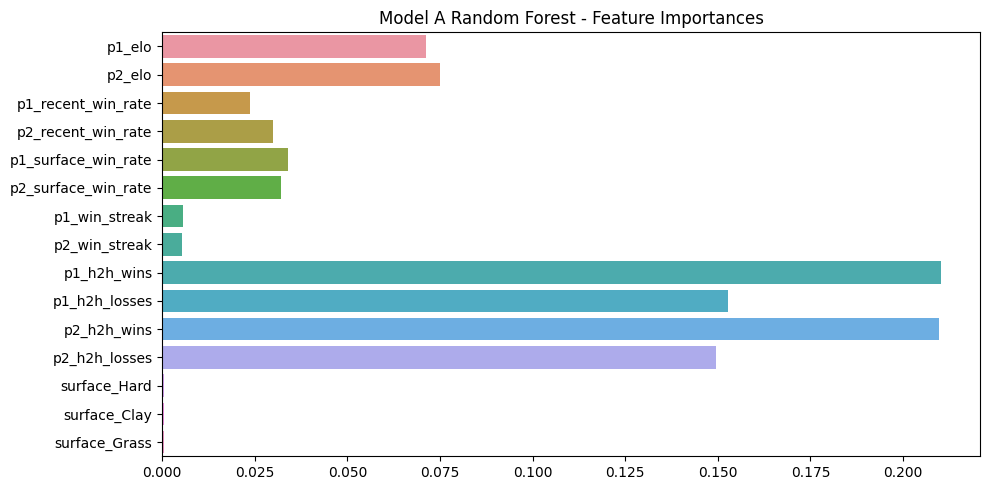

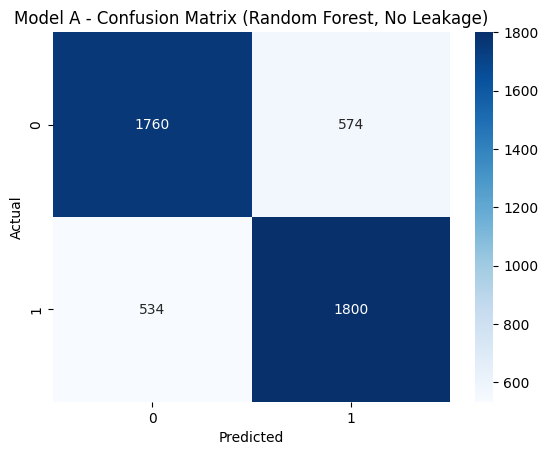

In [219]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random

# -- Prepare dataset
df_rf = pd.get_dummies(balanced_df.copy(), columns=['surface'], drop_first=False)
for col in ['surface_Hard', 'surface_Clay', 'surface_Grass']:
    if col not in df_rf.columns:
        df_rf[col] = 0
df_rf = df_rf.fillna(0)

# -- Feature set
feature_cols_A = [
    'p1_elo', 'p2_elo',
    'p1_recent_win_rate', 'p2_recent_win_rate',
    'p1_surface_win_rate', 'p2_surface_win_rate',
    'p1_win_streak', 'p2_win_streak',
    'p1_h2h_wins', 'p1_h2h_losses',
    'p2_h2h_wins', 'p2_h2h_losses',
    'surface_Hard', 'surface_Clay', 'surface_Grass'
]

# -- Leakage-free split by matchup
def split_by_matchup(df, test_frac=0.2, seed=42):
    df = df.copy()
    df['match_key'] = df.apply(lambda row: tuple(sorted([row['player_1'], row['player_2']])), axis=1)
    unique_keys = df['match_key'].unique()
    random.seed(seed)
    random.shuffle(unique_keys)
    test_keys = set(unique_keys[:int(len(unique_keys) * test_frac)])
    test_df = df[df['match_key'].isin(test_keys)].drop(columns='match_key')
    train_df = df[~df['match_key'].isin(test_keys)].drop(columns='match_key')
    return train_df, test_df

train_df_A, test_df_A = split_by_matchup(df_rf)

# -- Split features and labels
X_train_A = train_df_A[feature_cols_A]
y_train_A = train_df_A['outcome']
X_test_A = test_df_A[feature_cols_A]
y_test_A = test_df_A['outcome']

# -- Train Random Forest
model_A = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
model_A.fit(X_train_A, y_train_A)

# -- Predictions
y_pred_A = model_A.predict(X_test_A)
y_train_pred = model_A.predict(X_train_A)

# -- Accuracy scores
train_acc = accuracy_score(y_train_A, y_train_pred)
test_acc = accuracy_score(y_test_A, y_pred_A)

print("Train Accuracy:", round(train_acc, 4))
print("Leakage-Free Test Accuracy:", round(test_acc, 4))
print("\nClassification Report:")
print(classification_report(y_test_A, y_pred_A))

# -- Feature importances
importances = model_A.feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=feature_cols_A)
plt.title("Model A Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

# -- Confusion Matrix
cm = confusion_matrix(y_test_A, y_pred_A)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model A - Confusion Matrix (Random Forest, No Leakage)")
plt.show()
